In [1]:
# Base packages
import numpy as np
import matplotlib.pyplot as plt
import os
import copy

# I/O
import glob
from skimage import io
from PIL import Image
import h5py
import json
import pickle

# Plots
import seaborn as sns
import pandas as pd
from textwrap import wrap
import matplotlib.patheffects as path_effects
import statsmodels.api as sm

# Measurements and Metrics
from sklearn import metrics as skmetrics
from skimage import measure

In [2]:
def seg_contour_overlay(mask_list,
                        image,
                        line_size=4,
                        fig_size=(16,16),
                        thresh=0.5,
                        color_list = ['blue','lime','magenta','yellow','red'],
                        save_fig=False,
                        save_name='overlay.jpg',
                        show_fig=True,
                        title='Contour Overlay',
                        save_fig_dpi=150,
                        contour_alpha=0.75
                       ):
    
    contour_list = []
    for mask in mask_list:
        contour_list.extend([measure.find_contours(mask, thresh)])
    
    fig, ax = plt.subplots(figsize=fig_size)
    ax.imshow(image, cmap=plt.cm.gray, interpolation=None)
    
    color_select = 0
    for mask_contour in contour_list:
        for contour in mask_contour:
            ax.plot(contour[:, 1], contour[:, 0], linewidth=line_size, color=color_list[color_select],alpha=contour_alpha)
        color_select+=1

    ax.set_xticks([])
    ax.set_yticks([])
    plt.title(title, fontsize = 24)
    if save_fig:
        plt.savefig(save_name, dpi=save_fig_dpi, bbox_inches='tight', pad_inches = 0)
    if show_fig:
        plt.show()
    else:
        plt.close()

In [3]:
data_root = ''

unet_prediction_dir = data_root + 'final_UNetPlusPlus_output' + os.sep
unet_prediction_list = sorted(glob.glob(unet_prediction_dir + os.sep + '**' + os.sep + '*.h5', recursive=True))

rcnn_prediction_dir = data_root + 'final_RCNN_output_40' + os.sep
rcnn_prediction_list = sorted(glob.glob(rcnn_prediction_dir + os.sep + '**' + os.sep + '*.h5', recursive=True))

yolo_prediction_dir = data_root + 'final_YOLO_output_40' + os.sep
yolo_prediction_list = sorted(glob.glob(yolo_prediction_dir + os.sep + '**' + os.sep + '*.h5', recursive=True))

In [25]:
fusion_metric_arr = []
save_root = data_root + 'final_Fusion_output'
os.makedirs(save_root, exist_ok=True)

for img_no in range(len(unet_prediction_list)):
    unet_filename = unet_prediction_list[img_no]
    rcnn_filename = rcnn_prediction_list[img_no]
    yolo_filename = yolo_prediction_list[img_no]

    with h5py.File(unet_filename, 'r') as hdf:
        current_img = np.asarray(hdf['img'])
        current_gt = np.asarray(hdf['gt_mask'])
        unet_predict_mask = np.asarray(hdf['pr_map'])
        
    with h5py.File(rcnn_filename, 'r') as hdf:
        rcnn_predict_mask = np.asarray(hdf['pr_map'])
        
    with h5py.File(yolo_filename, 'r') as hdf:
        yolo_predict_mask = np.asarray(hdf['pr_map'])
        
    fusion_map = unet_predict_mask + rcnn_predict_mask + yolo_predict_mask
    
    # Threshold here
    current_predict_mask = fusion_map > 1.2
        
    bg_masked_name = unet_filename.replace('final_UNetPlusPlus_output', 'images_bgmasked')
    bg_masked_name = bg_masked_name.replace('_PredictionResults.h5', '_masked.png')
    bg_masked_img = Image.open(bg_masked_name)
    bg_masked_img = np.max(bg_masked_img, axis = 2)
    current_predict_mask[bg_masked_img == 0] = 0
    
    patient_name =  unet_filename.split('\\')[-2]
    current_image_name = unet_filename.split('\\')[-1].split('.')[0].replace('_PredictionResults.h5', '')
    os.makedirs(save_root + os.sep + patient_name, exist_ok=True)
    save_name = save_root + os.sep + patient_name + os.sep + current_image_name + '_PredictionResults.h5'

    with h5py.File(save_name, 'w') as hdf:
            hdf.create_dataset('img', data=current_img, dtype='uint8')
            hdf.create_dataset('gt_mask', data=(current_gt).astype('uint8'), dtype='uint8')
            hdf.create_dataset('pr_mask_optimum', data=(current_predict_mask*255).astype('uint8'), dtype='uint8')
            hdf.create_dataset('pr_map', data=(fusion_map).astype('double'), dtype='double')
    
    tp = 0
    fp = 0
    fn = 0
    
    gt_mask_labelled = measure.label(current_gt)
    pr_mask_labelled = measure.label(current_predict_mask)

    tp_map = np.zeros(current_gt.shape)
    fp_map = np.zeros(current_gt.shape)
    fn_map = np.zeros(current_gt.shape)

    matched_gt_list = []
    for pred_label in range (1,len(np.unique(pr_mask_labelled))):
        pr_mask_full = np.zeros(current_predict_mask.shape)
        pr_mask_full[pr_mask_labelled == pred_label] = 1

        matched_gt = -1
        iou_val = 0

        for region_label in range (1,len(np.unique(gt_mask_labelled))):
            if region_label not in matched_gt_list:
                current_region_mask = np.zeros(current_gt.shape)
                current_region_mask[gt_mask_labelled == region_label] = 1
                curr_iou = np.sum(pr_mask_full[current_region_mask == 1])/(np.sum(pr_mask_full) + np.sum(gt_mask_labelled == region_label) - np.sum(pr_mask_full[current_region_mask == 1]))
                if curr_iou > 0.01:
                    if curr_iou > iou_val:
                        iou_val = curr_iou
                        matched_gt = region_label
        if matched_gt != -1:
            tp += 1
            matched_gt_list.append(matched_gt)
            tp_map = np.maximum(pr_mask_full, tp_map)
        else:
            fp += 1
            fp_map = np.maximum(pr_mask_full, fp_map)
  
    fn = len(np.unique(gt_mask_labelled)) - len(matched_gt_list)
    for i in range (1,len(np.unique(gt_mask_labelled))):
        if i not in matched_gt_list:
            current_region_mask = np.zeros(current_gt.shape)
            current_region_mask[gt_mask_labelled == i] = 1
            fn_map = np.maximum(current_region_mask, fn_map)         
            
    print(tp)
    print(fp)
    print(fn)
    fusion_metric_arr.append(tp/(tp+fp) + tp/(tp+fn))
    
    seg_contour_overlay([tp_map,fp_map,fn_map],
            current_img,
            line_size=3,
            fig_size=(16,16),
            thresh=0.5,
            color_list = ['lime','blue','magenta','yellow','red'],
            save_fig=True,
            save_name='fusion_contour' + os.sep + unet_filename.split('\\')[-1].split('.')[0].replace('_PredictionResults.h5', '') + 'ColorCodedOverlay.jpg',
            show_fig=False,
            title='tp: ' + str(tp) + '\nfp: ' + str(fp) + '\nfn: ' + str(fn),
            save_fig_dpi=150,
            contour_alpha=1)

22
4
12
59
4
16
21
3
40
124
2
28
18
15
18
17
10
11
16
6
10
16
0
5
61
6
33
41
5
3
27
7
8
51
13
6
56
2
16
41
2
20
27
0
6
23
2
7
11
4
6
14
3
4
4
2
3
10
1
4
10
3
5
53
8
47
50
5
43
45
5
13
43
4
11
33
2
17
38
2
23
99
16
70
14
1
7
91
8
42
28
2
29
70
4
82
96
3
14
61
7
25
25
4
8
62
5
13
64
1
22
106
3
22
73
6
38
13
0
31
23
2
11
26
3
28
198
12
34
95
6
46
44
6
19
72
14
18
47
5
20
46
6
13
23
1
5
26
4
11
60
5
18
39
9
8
26
4
28
22
0
10
36
2
5
32
5
23
30
2
13
21
2
19
29
1
16
12
5
13
14
6
24
10
3
13
19
5
29
11
2
35
174
30
64
209
31
51


In [26]:
def add_median_labels(ax,color='white',foreground_color='white',fontsize=None,median_outline=False):
    lines = ax.get_lines()
    # determine number of lines per box (this varies with/without fliers)
    boxes = [c for c in ax.get_children() if type(c).__name__ == 'PathPatch']
    lines_per_box = int(len(lines) / len(boxes))
    # iterate over median lines
    median_list = []
    for median in lines[4:len(lines):lines_per_box]:
        # display median value at center of median line
        x, y = (data.mean() for data in median.get_data())
        # choose value depending on horizontal or vertical plot orientation
        value = x if (median.get_xdata()[1]-median.get_xdata()[0]) == 0 else y
        if fontsize is not None:
            text = ax.text(x, y, f'{value:.2f}', ha='center', va='center',
                           fontweight='bold', color=color, fontsize=fontsize)
        else:
            text = ax.text(x, y, f'{value:.2f}', ha='center', va='center',
                           fontweight='bold', color=color)
        
        if median_outline:
            # create median-colored border around white text for contrast
            text.set_path_effects([
                path_effects.Stroke(linewidth=3, foreground=foreground_color),#median.get_color()),
                path_effects.Normal(),
            ])
        median_list.extend([value])
    return median_list

In [27]:
def boxplot_full_set_v2(df,
                        colors = ["lightgreen", "lightyellow"],
                        figsize=(4.5,9),
                        median_labels = True,
                        swarmsize=6,
                        swarmpalette=['0.25','0.25'],
                        swarm_marker='o',
                        ylim=(-0.05,1.05),
                        fontsize=None,
                        savefig=False,
                        showfig=True,
                        savename='boxplot_v2',
                        gridlines="both",
                        title="Boxplot v2",
                        titlewrap=35,
                        xlabel='Group',
                        xlabel_size = None,
                        xtick_rotation = 0,
                        ylabel="Value",
                        ylabel_size = None,
                        y_axis_right=False,
                        median_color='white',
                        median_outline=False,
                        median_outline_color ='black',
                        median_fontsize=None,
                        show_means=False,
                        meanline=False,
                        meanprops={"marker":"o",
                                   "markerfacecolor":"white", 
                                   "markeredgecolor":"red",
                                   "markersize":"16"}
                       ):
    
    sns.set_palette(sns.color_palette(colors))
    sns.set_style("whitegrid", {"axes.grid.which":gridlines})
    
    if fontsize is not None:
        plt.rcParams.update({'font.size': fontsize})
        
    plt.figure(figsize=figsize)
        
    ax = sns.swarmplot(data=df,
                       #color=".25",
                       palette=swarmpalette,
                       size=swarmsize,
                       marker=swarm_marker)
    
    if show_means and meanline:
        ax = sns.boxplot(data=df,
                         fliersize=0,
                         showmeans=True,
                         meanline=True,
                         meanprops=meanprops
                        )
        print('meanline!')
    elif show_means:
        ax = sns.boxplot(data=df,
                         fliersize=0,
                         showmeans=True,
                         meanprops=meanprops
                        )
    
    else:
        ax = sns.boxplot(data=df,fliersize=0)
    
    if median_labels:
        add_median_labels(ax, median_color, median_outline_color, median_fontsize, median_outline=median_outline)

    plt.ylim(ylim)
    
    plt.title("\n".join(wrap(title,titlewrap)))
    
    if xlabel_size is None:
        plt.xlabel(xlabel)
    else:
        plt.xlabel(xlabel, fontsize=xlabel_size)
    
    if ylabel_size is None:
        plt.ylabel(ylabel)
    else:
        plt.ylabel(ylabel, fontsize=ylabel_size)
    
    if y_axis_right:
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")
    
    plt.xticks(rotation = xtick_rotation)
    
    if savefig:
        plt.savefig(savename + '.png', dpi=150, bbox_inches='tight')
        plt.savefig(savename + '.pdf', dpi=150, bbox_inches='tight')
    
    if showfig:
        plt.show()
    else:
        plt.close()
    
    if fontsize is not None:
        plt.rcParams.update({'font.size': default_fontsize})

In [28]:
fontsize = 18
plt.rcParams.update({'font.size': fontsize})
default_fontsize = fontsize

meanline!


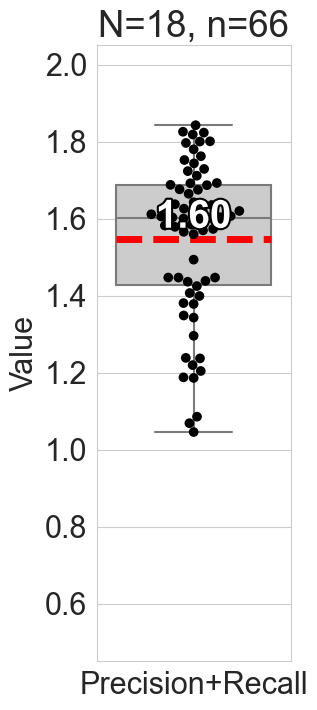

In [29]:
fusion_df = pd.DataFrame(
    {
        'Precision+Recall':fusion_metric_arr,
    }
)

boxplot_full_set_v2(fusion_df,
                 figsize=(2.5,8),
                 fontsize=22,
                 swarmsize=7,
                 savename="PrecisionRecall_UNet",
                 title='N=18, n=66',
                 titlewrap=25,
                 xlabel='',
                 ylabel='Value',
                 ylim=(0.45,2.05),
                 colors = ['0.8','0.8'],
                 #colors = ["#6BA3F0"],
                 swarmpalette=["0.0"],
                 median_labels=True,
                 median_color='white',
                 median_outline=True,
                 median_outline_color='0.0',
                 median_fontsize=28,
                 show_means=True,
                 meanline=True,
                 meanprops={"c":"red",
                           "ls":"--",
                           'linewidth':'5'},
                 savefig=False
                )